In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import make_classification
from sklearn.linear_model import Perceptron as SklearnPerceptron

In [71]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0, n_classes=2, n_clusters_per_class=1, class_sep=10, hypercube=False, random_state=41)

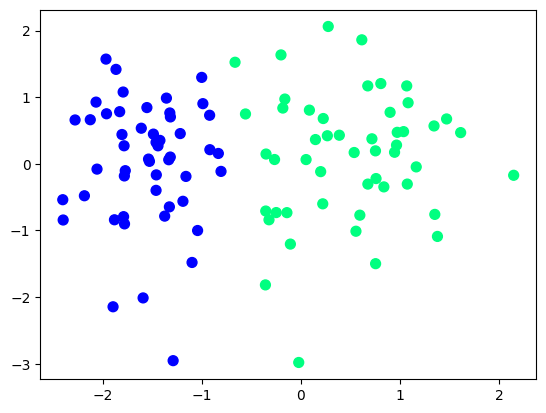

In [72]:
plt.scatter(X[:,0],X[:,1], c=y, cmap='winter',s=50)
plt.show()

In [73]:
class Sklearn_Perceptron:
  def __init__(self, epochs = 1000, lr = 0.1):
    self.lr = lr
    self.epochs = epochs

  def perceptron(self,X,y):
    sk_perceptron = SklearnPerceptron(random_state=42)
    sk_perceptron.fit(X, y)

    sk_coef = sk_perceptron.coef_[0]
    sk_intercept = sk_perceptron.intercept_[0]

    m_sk = -(sk_coef[0] / sk_coef[1])
    b_sk = -(sk_intercept / sk_coef[1])

    X_input_sk = np.linspace(-3, 3, 100)
    y_input_sk = m_sk * X_input_sk + b_sk

    plt.figure(figsize=(10,6))
    plt.plot(X_input_sk, y_input_sk, color='green', linestyle='--', label='Sklearn Perceptron Reg Line')
    plt.scatter(X[:,0],X[:,1], c=y, cmap='winter',s=50)
    plt.ylim(-3,2)
    plt.title('Sklearn Perceptron Decision Reg Line')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.show()

In [74]:
class Step:
  def __init__(self, epochs = 1000, lr = 0.1):
    self.lr = lr
    self.epochs = epochs

  def step_perceptron(self,X,y):
    X = np.insert(X, 0 , 1, axis = 1)
    W = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
      s = np.random.randint(0, 100)
      y_hat = self.step(np.dot(X[s], W))
      W = W + lr * (y[s] - y_hat) * X[s]
    return W[0], W[1:]

  def step(self, z):
    return 1 if z > 0 else 0

In [75]:
class Sigmoid:
  def __init__(self, epochs = 1000, lr = 0.1):
    self.lr = lr
    self.epochs = epochs

  def sigmoid_perceptron(self, X, y):
    X_biased = np.insert(X, 0 , 1, axis = 1)
    W = np.ones(X_biased.shape[1])
    lr = 0.1
    n_samples = X_biased.shape[0]
    bias = 1

    for i in range(10000):
      y_hat = self.sigmoid(np.dot(X_biased, W) + bias)

      dw = np.dot(X_biased.T, (y_hat - y)) / n_samples
      db = np.sum(y_hat - y) / n_samples

      W = W - lr * dw
      bias = bias - lr * db
    return W, bias

  def sigmoid(self, z):
    return 1 / (1 + np.exp(-z))  # using sigmoid function

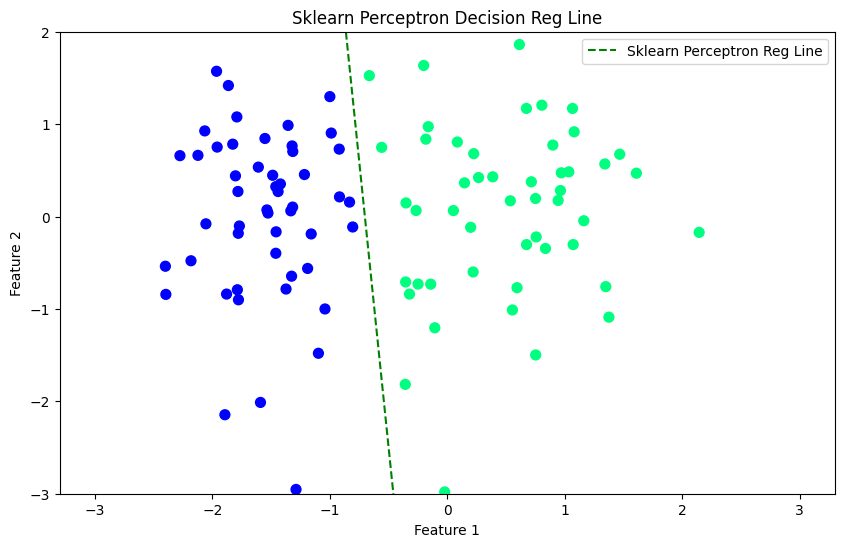

In [76]:
# Sklearn Perceptron
sk = Sklearn_Perceptron()
sk.perceptron(X, y)

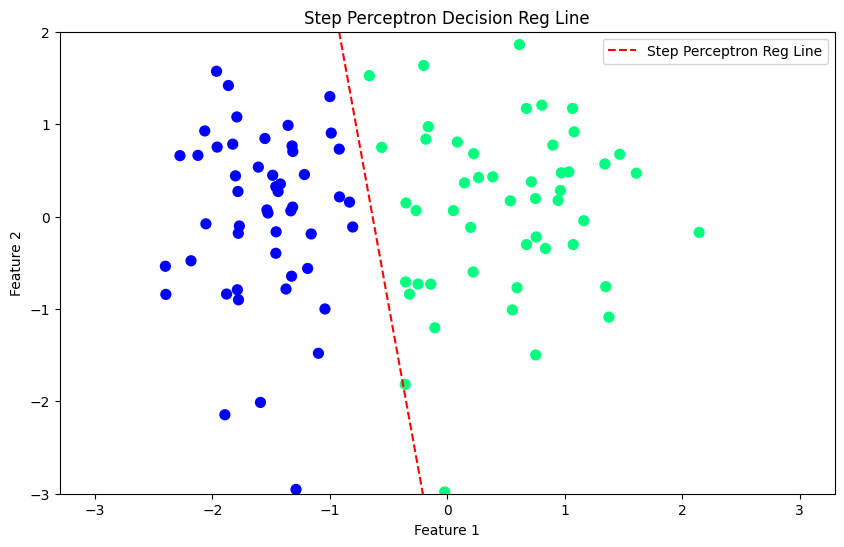

In [77]:
# Step Perceptron
step = Step()
bias_step, weights_step = step.step_perceptron(X, y)

m_step = -(weights_step[0] / weights_step[1])
b_step = -(bias_step / weights_step[1])

X_input_step = np.linspace(-3, 3, 100)
y_input_step = m_step * X_input_step + b_step

plt.figure(figsize=(10,6))
plt.plot(X_input_step, y_input_step, color='red', linestyle='--', label='Step Perceptron Reg Line')
plt.scatter(X[:,0],X[:,1], c=y, cmap='winter',s=50)
plt.ylim(-3,2)
plt.title('Step Perceptron Decision Reg Line')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

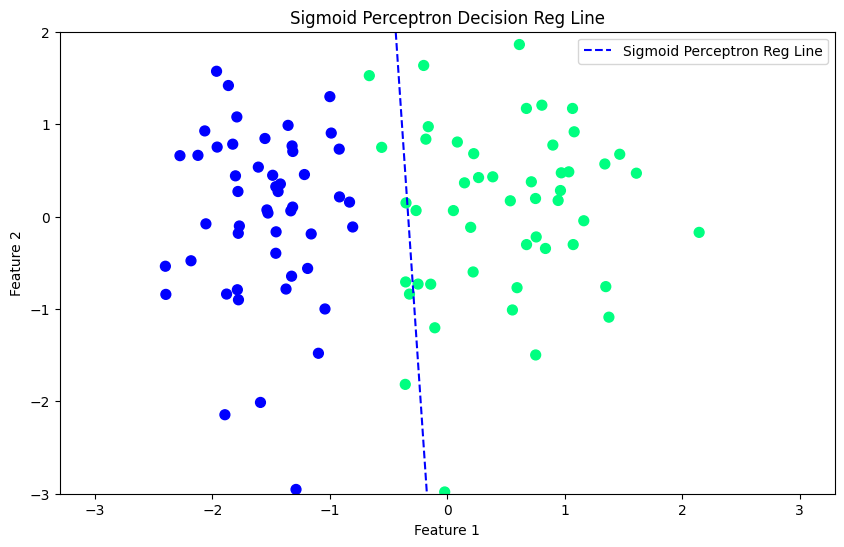

In [78]:
# Sigmoid Perceptron
sigmoid = Sigmoid()
W_sigmoid, bias_sigmoid = sigmoid.sigmoid_perceptron(X, y)

# Calculate the decision boundary for Sigmoid Perceptron
# The W_sigmoid from the function includes the bias term at index 0
m_sigmoid = -(W_sigmoid[1] / W_sigmoid[2])
b_sigmoid = -(W_sigmoid[0] / W_sigmoid[2])

X_input_sigmoid = np.linspace(-3, 3, 100)
y_input_sigmoid = m_sigmoid * X_input_sigmoid + b_sigmoid

plt.figure(figsize=(10,6))
plt.plot(X_input_sigmoid, y_input_sigmoid, color='blue', linestyle='--', label='Sigmoid Perceptron Reg Line')
plt.scatter(X[:,0],X[:,1], c=y, cmap='winter',s=50)
plt.ylim(-3,2)
plt.title('Sigmoid Perceptron Decision Reg Line')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

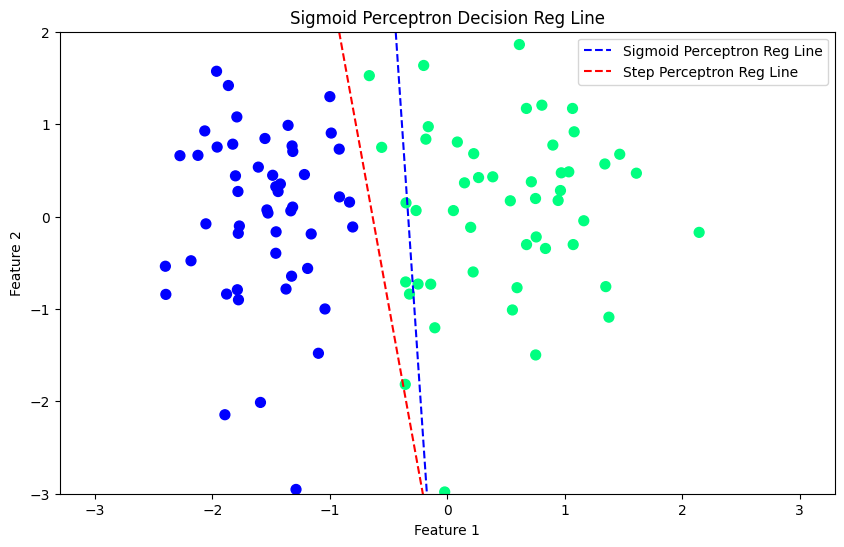

In [79]:
plt.figure(figsize=(10,6))
plt.plot(X_input_sigmoid, y_input_sigmoid, color='blue', linestyle='--', label='Sigmoid Perceptron Reg Line')
plt.plot(X_input_step, y_input_step, color='red', linestyle='--', label='Step Perceptron Reg Line')
# plt.plot(X_input_sk, y_input_sk, color='green', linestyle='--', label='Sklearn Perceptron Reg Line')
plt.scatter(X[:,0],X[:,1], c=y, cmap='winter',s=50)
plt.ylim(-3,2)
plt.title('Sigmoid Perceptron Decision Reg Line')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()